In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import modified_rf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from modified_rf import RandomForestRegressor621
from importlib import reload
from sklearn.linear_model import LinearRegression

reload(modified_rf)

np.random.seed(24)

def generate_study(features, n, w, tau, weight_variance, study_label):
    X = np.zeros([n, features])

    X = np.random.normal(0,1,(n,features))

    '''
    Fraction of first n weights are relevant (Weight variance parameter), the rest are 0
    '''
    beta = np.arange(0,features)
    #w = 10
    weights = np.zeros(features)
    weights = beta + (np.random.rand(features)-0.5) * tau * 2

    keep = int(weight_variance * w)
    keep_indices = np.random.choice(w, size=keep, replace=False)
    temp = np.zeros(w)
    temp[keep_indices] = weights[keep_indices]
    weights[:w] = temp
    weights[w:] = 0
    #weights[-1] = beta[-1]

    
    y = np.dot(X,weights)# + np.exp(X[:,0])
    labels = [study_label]*n
    X = np.column_stack([X,labels])
    #print(weights)
    return X,y

features = 50
w = 10 #weighted features
tau = 5 #inter-study variance
weight_variance = .8 #change in which w are weighted between studies
n = 100

X,y = generate_study(features = features, n = n, w=w, tau = tau, weight_variance = weight_variance, study_label = 0)


for i in range(1,10):
    X_temp,y_temp = generate_study(features = features, n = n, w=w, tau = tau, weight_variance = weight_variance, study_label = i)
    X = np.concatenate((X,X_temp), axis = 0)
    y = np.concatenate((y,y_temp), axis = 0)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

In [43]:
def forest(label_depth, n_estimators, thick_trunk = False):
    rf1 = RandomForestRegressor621(n_estimators=n_estimators, min_samples_leaf=1, max_features = 0.5, max_depth=None, label_depth=label_depth, thick_trunk=thick_trunk, force_label_split=False, oob_score=False)
    # Fit the model to the training data
    rf1.fit(X_train, y_train)

    # Make predictions on new data
    predictions = rf1.predict(X_test)

    # Calculate the accuracy score for the predictions
    accuracy_score = rf1.score(X_test, y_test)
    print("\nLinear Test Accuracy:",accuracy_score)

    train_score = rf1.score(X_train, y_train)
    print("\n Training Accuracy:",train_score)
    
    return train_score, accuracy_score, rf1
'''
train_score, accuracy_score, rf0 = forest(None, 100)
train_score, accuracy_score, rf1 = forest(0, 100)
train_score, accuracy_score, rf2 = forest(3, 100)
'''

'\ntrain_score, accuracy_score, rf0 = forest(None, 100)\ntrain_score, accuracy_score, rf1 = forest(0, 100)\ntrain_score, accuracy_score, rf2 = forest(3, 100)\n'

In [26]:
sklearn_rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, max_features=0.5, max_depth = None, oob_score=False)
sklearn_rf.fit(X_train[:,:-1], y_train)
sklearn_predictions = sklearn_rf.predict(X_test[:,:-1])
sklearn_accuracy_score = sklearn_rf.score(X_test[:,:-1], y_test)
print(sklearn_accuracy_score)

sklearn_predictions = sklearn_rf.predict(X_train[:,:-1])
sklearn_accuracy_score = sklearn_rf.score(X_train[:,:-1], y_train)
print(sklearn_accuracy_score)

0.41672681681843027
0.813119724659004


In [27]:
lr = LinearRegression()
lr.fit(X_train, y_train)
print(lr.score(X_test,y_test))

0.8275087571921592


In [ ]:
rf = RandomForestRegressor(
    warm_start=True,      # allows incremental growing
    oob_score=True,
    bootstrap=True,
    min_samples_leaf = 5,
    max_features = 'sqrt'
)

oob_scores = []
n_trees_range = range(20, 1000)

for n in n_trees_range:
    rf.set_params(n_estimators=n)
    rf.fit(X_train, y_train)
    oob_scores.append(rf.oob_score_)
    #print(n)

plt.plot(n_trees_range, oob_scores)
plt.xlabel("Number of Trees")
plt.ylabel("OOB R²")
plt.title("OOB Score vs Number of Trees")
plt.show()

In [36]:
#Accuracy at different label depths
train_score_thin = []
accuracy_score_thin = []
rf_thin = []

for i in range(15):
    temp_train_score, temp_accuracy_score, temp_rf1 = forest(i, 500, thick_trunk=False)
    train_score_thin.append(temp_train_score)
    accuracy_score_thin.append(temp_accuracy_score)
    rf_thin.append(temp_rf1)

'''
train_score_thick = []
accuracy_score_thick = []
rf_thick = []

for i in range(15):
    temp_train_score, temp_accuracy_score, temp_rf1 = forest(i, 500, thick_trunk=True)
    train_score_thick.append(temp_train_score)
    accuracy_score_thick.append(temp_accuracy_score)
    rf_thick.append(temp_rf1)


#depth = np.arange(25)
#plt.plot(depth, accuracy_score, label = 'Label splitting')
'''
delabeled_train_score, delabeled_accuracy_score, delabeled_rf1 = forest(None, 200)

sklearn_rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, max_features=0.5, max_depth = None, oob_score=False)
sklearn_rf.fit(X_train[:,:-1], y_train)
sklearn_predictions = sklearn_rf.predict(X_test[:,:-1])
sklearn_accuracy_score = sklearn_rf.score(X_test[:,:-1], y_test)




Tree: 499
Linear Test Accuracy: 0.5704728559528003

 Training Accuracy: 0.9262258574272747
Tree: 499
Linear Test Accuracy: 0.5882508131992306

 Training Accuracy: 0.9345566409481671
Tree: 499
Linear Test Accuracy: 0.5871166455929939

 Training Accuracy: 0.927166996910623
Tree: 499
Linear Test Accuracy: 0.5690308687510617

 Training Accuracy: 0.9198348119208363
Tree: 499
Linear Test Accuracy: 0.5809168778604361

 Training Accuracy: 0.9300023711932639
Tree: 499
Linear Test Accuracy: 0.5661319527088922

 Training Accuracy: 0.9289830816329548
Tree: 499
Linear Test Accuracy: 0.5613425890622166

 Training Accuracy: 0.9227657099402343
Tree: 499
Linear Test Accuracy: 0.5312204243673624

 Training Accuracy: 0.9182994319248006
Tree: 499
Linear Test Accuracy: 0.5198877962953317

 Training Accuracy: 0.9174000629126351
Tree: 499
Linear Test Accuracy: 0.5215635871587426

 Training Accuracy: 0.9186337951400074
Tree: 499
Linear Test Accuracy: 0.5071829616352537

 Training Accuracy: 0.9034295194875221


'\nfeatures = 50\nw = 30 #weighted features\ntau = 5 #inter-study variance\nweight_variance = .8 #change in which w are weighted between studies\nn = 100\n'

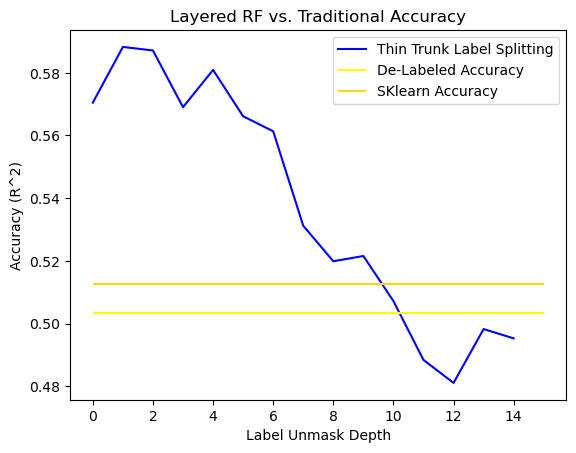

In [41]:
depth = np.arange(15)
plt.plot(depth, accuracy_score_thin, label = 'Thin Trunk Label Splitting', color = 'blue')
#plt.plot(depth, accuracy_score_thick, label = 'Thick Trunk Label Splitting', color = 'dodgerblue')
#Base Accuracy

plt.hlines(delabeled_accuracy_score, 0, 15, label = 'De-Labeled Accuracy', color = 'yellow')

#Sklearn accuracy
plt.hlines(sklearn_accuracy_score, 0, 15, label = "SKlearn Accuracy", color = 'gold')
plt.legend()
plt.xlabel('Label Unmask Depth')
plt.ylabel('Accuracy (R^2)')
plt.title('Layered RF vs. Traditional Accuracy')

'''
features = 50
w = 30 #weighted features
tau = 5 #inter-study variance
weight_variance = .8 #change in which w are weighted between studies
n = 100
'''

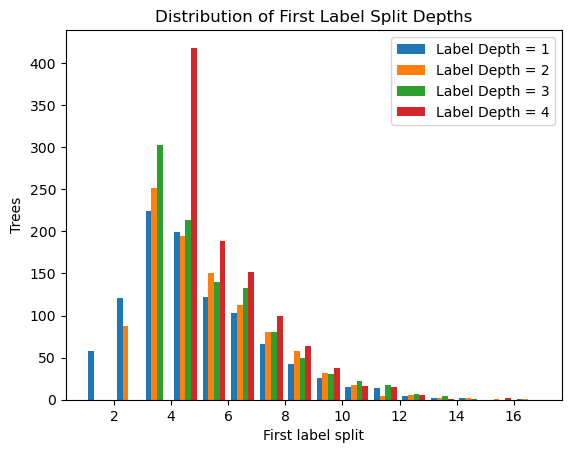

In [21]:
flsd = []
for i in range(15):
    flsd_temp = np.zeros(len(rf_thick[i].trees))
    for j in range(len(rf_thick[i].trees)):
        flsd_temp[j] = rf_thick[i].trees[j][0].first_label_split_depth
    flsd.append(flsd_temp)

plt.hist(flsd[1:5], stacked=False, bins = 16, label = ['Label Depth = 1', 'Label Depth = 2', 'Label Depth = 3', 'Label Depth = 4'])
plt.ylabel('Trees')
plt.xlabel('First label split')
plt.title('Distribution of First Label Split Depths')
plt.legend()

In [38]:
def forest(label_depth, n_estimators):
    rf1 = RandomForestRegressor621(n_estimators=n_estimators, min_samples_leaf=1, max_features=0.5, max_depth=None, label_depth=label_depth, force_label_split=False, oob_score=False)
    # Fit the model to the training data
    rf1.fit(X_train, y_train)

    # Make predictions on new data
    predictions = rf1.predict(X_test)

    # Calculate the accuracy score for the predictions
    accuracy_score = rf1.score(X_test, y_test)
    print("\nLinear Test Accuracy:",accuracy_score)
    
    train_score = rf1.score(X_train, y_train)
    print("\n Training Accuracy:",train_score)

    #calculate accuracy for each dataset in Xtest
    unique_vals = np.unique(X[:, -1])  # get unique values in last column
    sourced_X_test = []
    sourced_train_score = []
    for val in unique_vals:
        sourced_test = X_test[X_test[:, -1] == val]
        sourced_key = y_test[X_test[:, -1] == val]
        sourced_X_test.append(sourced_test)
        sourced_train_score.append(rf1.score(sourced_test, sourced_key))


    return train_score, accuracy_score, rf1, sourced_train_score

In [39]:
train_score = []
accuracy_score = []
rf1 = []
sourced_accuracy_scores=[]

for i in range(10):
    #print("forest", i)
    temp_train_score, temp_accuracy_score, temp_rf1, sourced_accuracy_score = forest(i, 500)
    train_score.append(temp_train_score)
    accuracy_score.append(temp_accuracy_score)
    rf1.append(temp_rf1)
    sourced_accuracy_scores.append(sourced_accuracy_score)

sourced_accuracy_scores = np.array(sourced_accuracy_scores)

Tree: 499
Linear Test Accuracy: 0.5883558942321188

 Training Accuracy: 0.9346055298182019
Tree: 499
Linear Test Accuracy: 0.5791336002784804

 Training Accuracy: 0.930619543949622
Tree: 499
Linear Test Accuracy: 0.5897463886915153

 Training Accuracy: 0.9348426171769797
Tree: 499
Linear Test Accuracy: 0.5629012755165996

 Training Accuracy: 0.8991923941085099
Tree: 499
Linear Test Accuracy: 0.5728361287507493

 Training Accuracy: 0.8942148438883906
Tree: 499
Linear Test Accuracy: 0.5638704476225023

 Training Accuracy: 0.9188999555380656
Tree: 499
Linear Test Accuracy: 0.5200116934046393

 Training Accuracy: 0.8895123609133275
Tree: 499
Linear Test Accuracy: 0.5298782025035028

 Training Accuracy: 0.9021164752553423
Tree: 499
Linear Test Accuracy: 0.5223206204624908

 Training Accuracy: 0.9120820288193915
Tree: 499
Linear Test Accuracy: 0.5184005226828783

 Training Accuracy: 0.896006926220046


Text(0.5, 1.0, 'Sourced Accuracy on Artificial Data')

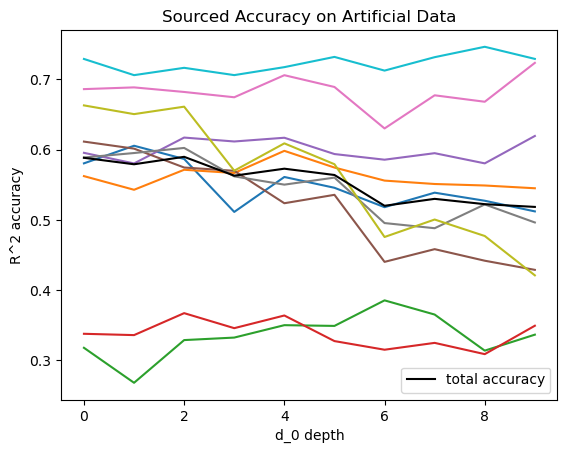

In [40]:
depth = np.arange(10)
for i in range(10):
    plt.plot(depth, sourced_accuracy_scores[:,i])
plt.plot(depth, accuracy_score, color = 'black', label = "total accuracy")
plt.xlabel('d_0 depth')
plt.ylabel('R^2 accuracy')
plt.legend()
plt.title("Sourced Accuracy on Artificial Data")